In [3]:
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [4]:
import sklearn
print(sklearn.__version__)

1.9.0


In [5]:
import os
import pandas as pd

# إنشاء مجلد data لو غير موجود
os.makedirs('../data', exist_ok=True)

# بيانات تجريبية مطابقة لمتطلبات المشروع
sample_data = {
    'carpet_area': [1000, 1200, 850, 1500, 2000, 950, 1100, 1800],
    'bedrooms': [2, 3, 2, 3, 4, 2, 3, 4],
    'bathrooms': [2, 2, 1, 3, 3, 2, 2, 3],
    'location': [
        'Mumbai',
        'Bangalore',
        'Delhi',
        'Mumbai',
        'Pune',
        'Bangalore',
        'Delhi',
        'Mumbai',
    ],
    'price': [
        '1.2 Cr',
        '85 Lac',
        '65 Lakh',
        '2.1 Cr',
        '1.5 Cr',
        '90 Lac',
        '75 Lakh',
        '2.8 Cr',
    ],
}

df_sample = pd.DataFrame(sample_data)
df_sample.to_csv('../data/house_prices.csv', index=False)
print('Done!')

Done!


In [6]:
#1.Load Data
df = pd.read_csv('../data/house_prices.csv')


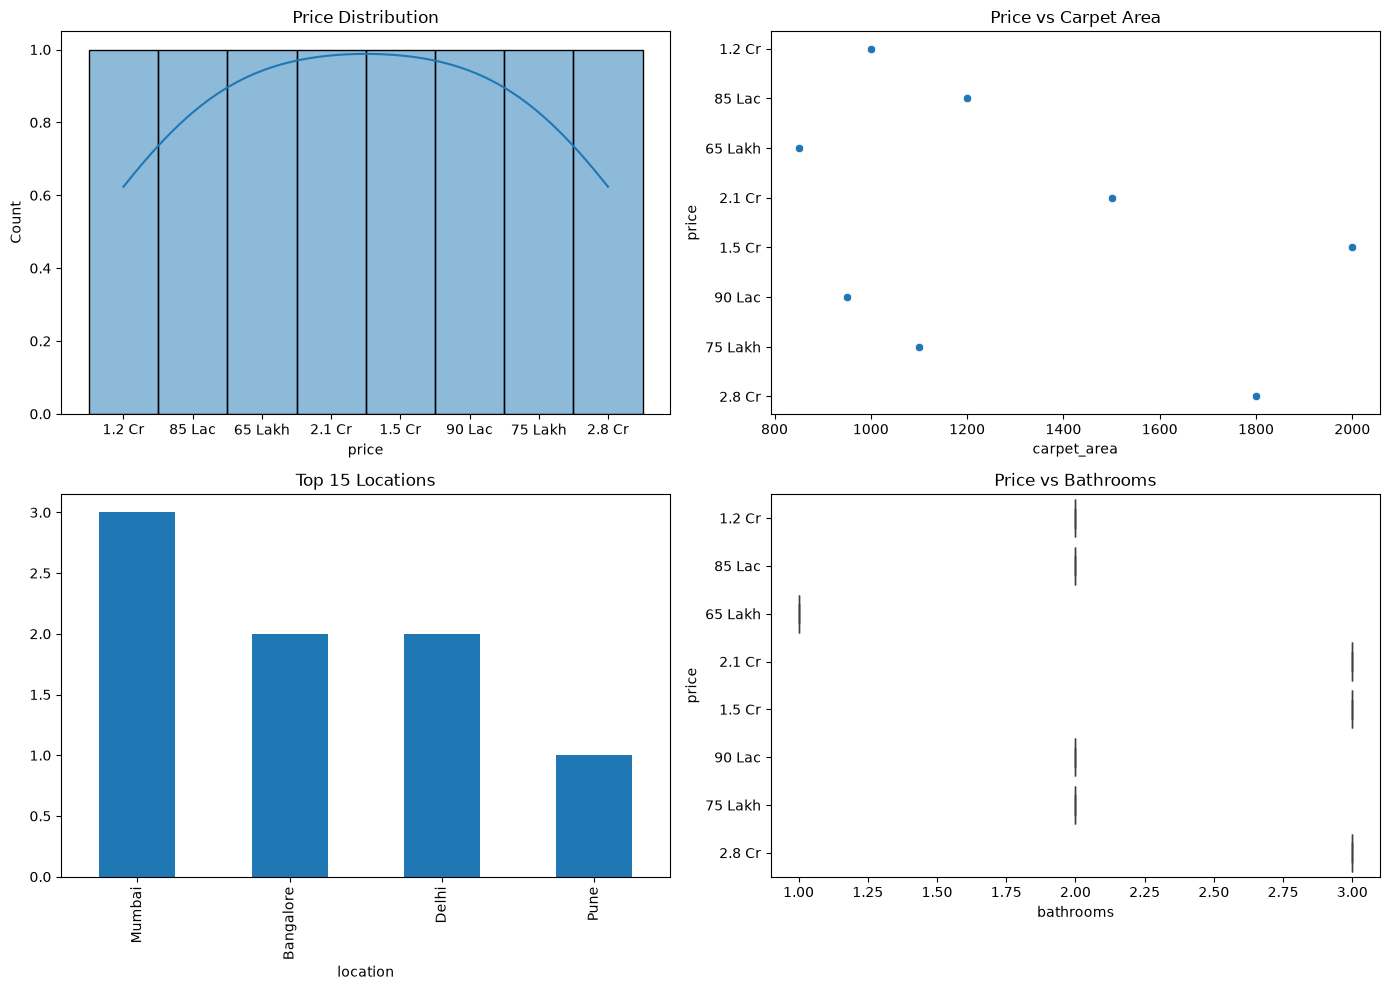

In [7]:
# 2. EDA - Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['price'], kde=True, ax=axes[0, 0]).set_title(
    'Price Distribution'
)
sns.scatterplot(x='carpet_area', y='price', data=df, ax=axes[0, 1]).set_title(
    'Price vs Carpet Area'
)
df['location'].value_counts().head(15).plot(
    kind='bar', ax=axes[1, 0], title='Top 15 Locations'
)
sns.boxplot(x='bathrooms', y='price', data=df, ax=axes[1, 1]).set_title(
    'Price vs Bathrooms'
)
plt.tight_layout()
plt.savefig('../notebooks/eda_plots.png')

In [8]:
# 3. Data Cleaning
import os
os.makedirs('../backend/models', exist_ok=True)
def parse_price(val):
  if pd.isna(val):
    return np.nan
  val = str(val).lower().strip()
  if 'cr' in val:
    return float(val.replace('cr', '').strip()) * 10000000
  elif 'lac' in val or 'lakh' in val:
    return float(val.replace('lac', '').replace('lakh', '').strip()) * 100000
  try:
    return float(val)
  except:
    return np.nan


df['price_numeric'] = df['price'].apply(parse_price)
df = df.dropna(subset=['price_numeric'])

top_locations = df['location'].value_counts().head(50).index.tolist()
df['location_clean'] = df['location'].apply(
    lambda x: x if x in top_locations else 'other'
)

with open('../backend/models/locations.json', 'w') as f:
  json.dump(top_locations + ['other'], f)


In [9]:

# 4. Pipeline Setup
numeric_features = ['carpet_area', 'bedrooms', 'bathrooms']
categorical_features = ['location_clean']

num_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]
)

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='other')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features),
])

X = df[numeric_features + categorical_features]
y = df['price_numeric']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import joblib

best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

best_pipeline.fit(X_train, y_train)

joblib.dump(best_pipeline, '../backend/models/house_price.pkl')
print("Model saved successfully!")

Model saved successfully!
